# Test Task for Data Science

#### Load data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef
from lightgbm import LGBMClassifier

RANDOM_STATE = 42
N_SPLITS = 5

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# First column is without name, it's an ID column
ID_COL = train.columns[0]
TARGET_COL = "target_class"

train_ids = train[ID_COL].values
test_ids = test[ID_COL].values

X = train.drop(columns=[ID_COL, TARGET_COL])
y = train[TARGET_COL].astype(int)

X_test = test.drop(columns=[ID_COL])

In [3]:
X.head()

,ses_rec,ses_rec_avg,ses_rec_sd,ses_rec_cv,user_rec,ses_n,ses_n_r,int_n,int_n_r,tran_n,...,int_cat15_n,int_cat16_n,int_cat17_n,int_cat18_n,int_cat19_n,int_cat20_n,int_cat21_n,int_cat22_n,int_cat23_n,int_cat24_n
0,13.0,2.500000,2.500000,1.000000,19.000000,3.000000,0.157895,4.0,1.333333,0.0,...,0,0,0,0,0,0,0,4,0,0
1,26.0,2.000000,0.000000,0.000000,32.000000,3.000000,0.093750,3.0,1.000000,0.0,...,0,0,0,0,0,0,1,1,0,0
2,22.0,0.000000,0.000000,-1.000000,22.000000,2.000000,0.090909,3.0,1.500000,0.0,...,0,0,0,0,0,0,0,3,0,0
3,0.0,0.082336,0.082336,-0.670656,0.329344,2.164672,-0.588320,5.0,2.362773,0.0,...,0,0,5,0,0,0,0,0,0,0
4,24.0,0.000000,0.000000,-1.000000,24.000000,2.000000,0.083333,4.0,2.000000,0.0,...,0,0,4,0,0,0,0,0,0,0


#### EDA

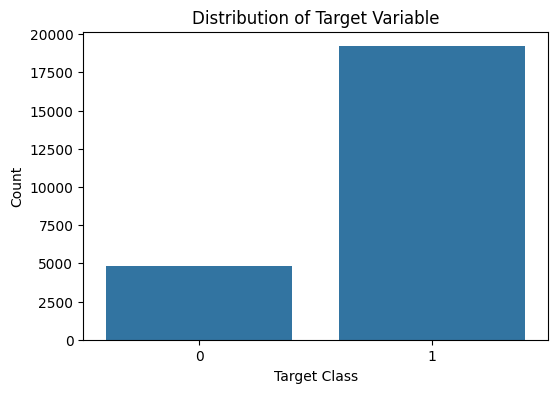

In [4]:
def print_distribution(data):
    plt.figure(figsize=(6, 4))
    sns.countplot(x="target_class", data=data)
    plt.title("Distribution of Target Variable")
    plt.xlabel("Target Class")
    plt.ylabel("Count")
    plt.show()


print_distribution(train)

The classes are unbalanced in the ratio of 20/80. The decision is to use `LGBMClassifier` - a gradient boosting classifier that uses decision trees to perform classification tasks, because tree-based algorithms are insensitive to imbalance as well as possible outliers.

#### Modeling

In [5]:
model_params = dict(
    n_estimators=6000,
    learning_rate=0.015,
    num_leaves=63,
    min_child_samples=15,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=0.1,
    class_weight=None,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

oof_proba = np.zeros(len(X))
test_proba = np.zeros(len(X_test))

#### Cross-validation

In [12]:
def matthews_corrcoef_eval(y_true, y_pred):
    y_pred_binary = (y_pred > 0.5).astype(int)
    mcc = matthews_corrcoef(y_true, y_pred_binary)
    return "matthews_corrcoef", mcc, True


for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y), 1):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    model = LGBMClassifier(
        **model_params
    )

    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric=matthews_corrcoef_eval,
    )

    oof_proba[va_idx] = model.predict_proba(X_va)[:, 1]
    test_proba += model.predict_proba(X_test)[:, 1] / N_SPLITS

[LightGBM] [Info] Number of positive: 15360, number of negative: 3840
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025066 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5941
[LightGBM] [Info] Number of data points in the train set: 19200, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.800000 -> initscore=1.386294
[LightGBM] [Info] Start training from score 1.386294
[LightGBM] [Info] Number of positive: 15360, number of negative: 3840
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000650 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5916
[LightGBM] [Info] Number of data points in the train set: 19200, number of used features: 42
[LightGBM] [Info] [bin

#### MCC threshold optimization

Training consists of choosing the best threshold value, depending on which іфьзду belongs to one of two classes. By default, it is 0.5.

In [13]:
thresholds = np.linspace(0.05, 0.95, 181)
mcc_scores = [matthews_corrcoef(y, (oof_proba >= t).astype(int)) for t in thresholds]

best_idx = int(np.argmax(mcc_scores))
best_t = thresholds[best_idx]
best_mcc = mcc_scores[best_idx]

print(f"Best CV MCC: {best_mcc:.5f}")
print(f"Best threshold: {best_t:.3f}")

Best CV MCC: 0.88943
Best threshold: 0.685


#### Final prediction

In [14]:
test_pred = (test_proba >= best_t).astype(int)

submission = pd.DataFrame({"ID": test_ids, "target": test_pred})

submission.to_csv("results.csv", index=False)
print("Saved results.csv")

Saved results.csv
